 Imports & Configuration

In [1]:
import warnings
warnings.filterwarnings('ignore')

# Core
import numpy as np
import pandas as pd
from IPython.display import display
from pathlib import Path

# Visualisation
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from matplotlib.gridspec import GridSpec
from matplotlib.patches import Patch

# Stats
from scipy import stats
from scipy.stats import chi2_contingency, mannwhitneyu, shapiro, ks_2samp

# ── Configuration Minimaliste
plt.rcParams.update({
    'figure.dpi':        150,
    'figure.facecolor':  '#FFFFFF',   # Fond d'image blanc pur
    'axes.facecolor':    '#FFFFFF',   # Fond de graphique blanc pur
    'axes.edgecolor':    '#E0E0E0',   # Bordures grises très douces
    'axes.labelcolor':   '#333333',   # Texte gris foncé (plus lisible que noir pur)
    'axes.titlecolor':   '#111111',   # Titre très foncé
    'axes.titlesize':    14,
    'axes.labelsize':    11,
    'xtick.color':       '#555555',   
    'ytick.color':       '#555555',
    'text.color':        '#333333',   
    'grid.color':        '#F0F0F0',   # Grille très discrète
    'grid.linestyle':    '-',         # Ligne continue pour plus de propreté
    'grid.alpha':        0.8,
    'legend.facecolor':  '#FFFFFF',
    'legend.edgecolor':  '#E0E0E0',
    'legend.fontsize':   10,
    'font.family':       'sans-serif',
    'axes.spines.top':   False,       # Supprime la bordure du haut (Minimalisme)
    'axes.spines.right': False,       # Supprime la bordure de droite (Minimalisme)
})

# ── Couleurs Métiers (Fraude vs Légitime) ───────────────────
# Approche classique et très lisible en présentation
FRAUD_COLOR  = '#D32F2F'   # Rouge vif (Alerte, Danger)
LEGIT_COLOR  = '#1976D2'   # Bleu corporatif (Confiance, Standard)
ACCENT_COLOR = '#FFA000'   # Ambre/Orange pour souligner des anomalies spécifiques
PALETTE      = [LEGIT_COLOR, FRAUD_COLOR]

# Appliquer la palette à Seaborn
sns.set_palette(PALETTE)

CHARGEMENT DES DONNÉEs ET PREMIÈRES INSPECTIONS

In [2]:
df = pd.read_csv('../data/raw/credit_card_fraud_10k.csv')

print("=" * 60)
print(" DATASET OVERVIEW")
print("=" * 60)
print(f"  Rows        : {df.shape[0]:,}")
print(f"  Columns     : {df.shape[1]}")
print(f"  Memory Usage: {df.memory_usage(deep=True).sum() / 1e6:.2f} MB")
print(f"  Hour Range  : {df['transaction_hour'].min():.0f}h  →  {df['transaction_hour'].max():.0f}h")
print(f"  Amount Range: ${df['amount'].min():.2f}  →  ${df['amount'].max():,.2f}")
print()
fraud_count = df['is_fraud'].sum()
legit_count = len(df) - fraud_count
fraud_pct   = fraud_count / len(df) * 100
print(f"  - Legitimate : {legit_count:,}  ({100 - fraud_pct:.2f}%)")
print(f"  - Fraudulent : {fraud_count:,}  ({fraud_pct:.4f}%)")
print()
print("First 5 rows:")
display(df.head())

 DATASET OVERVIEW
  Rows        : 10,000
  Columns     : 10
  Memory Usage: 1.28 MB
  Hour Range  : 0h  →  23h
  Amount Range: $0.00  →  $1,471.04

  - Legitimate : 9,849  (98.49%)
  - Fraudulent : 151  (1.5100%)

First 5 rows:


,transaction_id,amount,transaction_hour,merchant_category,foreign_transaction,location_mismatch,device_trust_score,velocity_last_24h,cardholder_age,is_fraud
0,1,84.47,22,Electronics,0,0,66,3,40,0
1,2,541.82,3,Travel,1,0,87,1,64,0
2,3,237.01,17,Grocery,0,0,49,1,61,0
3,4,164.33,4,Grocery,0,1,72,3,34,0
4,5,30.53,15,Food,0,0,79,0,44,0


AUDIT DE QUALITÉ DES DONNÉES

In [3]:
print("=" * 60)
print(" RAPPORT DE QUALITÉ DES DONNÉES")
print("=" * 60)

# Valeurs manquantes
missing = df.isnull().sum()
print(f"\n  Valeurs manquantes : {missing.sum()} (le dataset est complet)")

# Doublons
dupes = df.duplicated().sum()
print(f" Lignes dupliquées : {dupes:,}")
if dupes > 0:
    df = df.drop_duplicates()
    print(f"   → Doublons supprimés. Nouvelle dimension : {df.shape}")

# Types de données
print("\n Types de données des colonnes :")
print(df.dtypes.to_string())

# Statistiques basiques pour les montants
print("\n Montant des transactions — Statistiques clés :")
amt_stats = df.groupby('is_fraud')['amount'].describe()
amt_stats.index = ['Légitime', 'Fraude'] # Changement des index du tableau
display(amt_stats.round(2))

# Statistiques sur l'heure de transaction
print(f"\n   Plage d'heures des transactions : {df['transaction_hour'].min()}h → {df['transaction_hour'].max()}h")
print(f"   Heures uniques dans les données : {df['transaction_hour'].nunique()}")

 RAPPORT DE QUALITÉ DES DONNÉES

  Valeurs manquantes : 0 (le dataset est complet)
 Lignes dupliquées : 0

 Types de données des colonnes :
transaction_id           int64
amount                 float64
transaction_hour         int64
merchant_category          str
foreign_transaction      int64
location_mismatch        int64
device_trust_score       int64
velocity_last_24h        int64
cardholder_age           int64
is_fraud                 int64

 Montant des transactions — Statistiques clés :


,count,mean,std,min,25%,50%,75%,max
Légitime,9849.0,175.33,173.99,0.00,50.99,122.11,241.65,1471.04
Fraude,151.0,216.18,248.12,0.11,41.53,118.94,341.70,1185.07



   Plage d'heures des transactions : 0h → 23h
   Heures uniques dans les données : 24


VISUALISATION DE L'IMBALANCE DES CLASSES

Graphique sauvegardé avec succès dans : C:\Users\Lenovo T470\OneDrive\Documents\GitHub\fraud-detection-realtime\notebooks\plots\class_imbalance.png


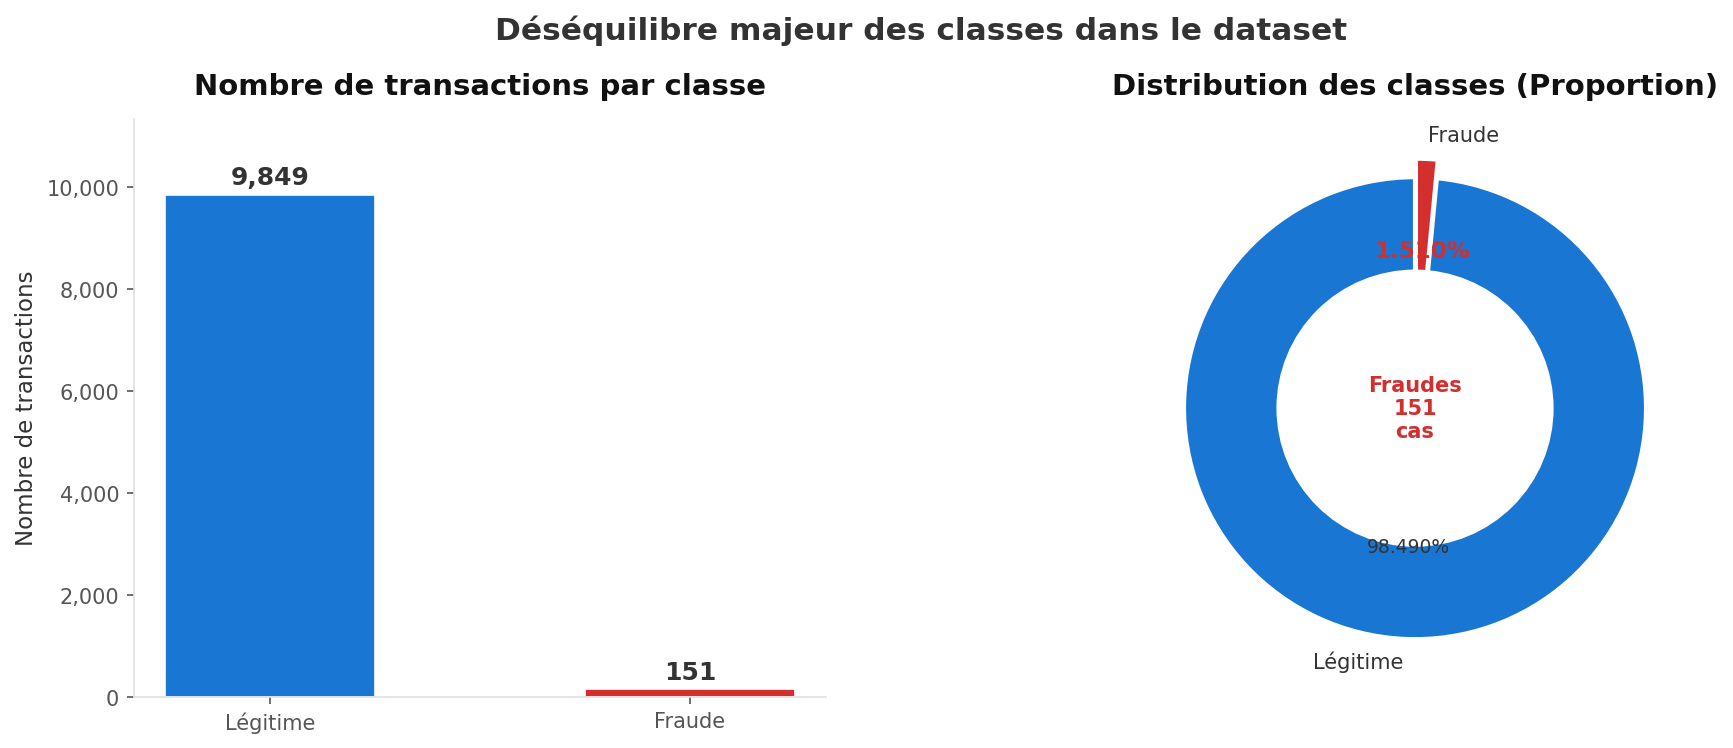

In [6]:
BASE_DIR = Path().resolve().parent
PLOT_DIR = BASE_DIR / 'notebooks' / 'plots'


fig = plt.figure(figsize=(14, 5))
gs  = GridSpec(1, 2, figure=fig, wspace=0.35)

class_counts = df['is_fraud'].value_counts().sort_index()
labels       = ['Légitime', 'Fraude']

# ── Gauche : Diagramme en barres ────────────────────────────
ax1 = fig.add_subplot(gs[0])
bars = ax1.bar(labels, class_counts.values, color=PALETTE,
               edgecolor='white', linewidth=0.8, width=0.5)

# Ajout des valeurs au-dessus des barres
for bar, val in zip(bars, class_counts.values):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
             f'{val:,}', ha='center', va='bottom', fontsize=12, fontweight='bold')

ax1.set_title('Nombre de transactions par classe', fontsize=14, fontweight='bold', pad=12)
ax1.set_ylabel('Nombre de transactions')
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax1.set_ylim(0, class_counts.max() * 1.15)

# ── Droite : Diagramme en anneau (Donut) ────────────────────
ax2 = fig.add_subplot(gs[1])
sizes   = [class_counts[0], class_counts[1]]
explode = (0, 0.08)

wedges, texts, autotexts = ax2.pie(
    sizes, labels=labels, colors=PALETTE, autopct='%1.3f%%',
    startangle=90, explode=explode,
    wedgeprops=dict(edgecolor='white', linewidth=2),
    textprops=dict(fontsize=10)
)

autotexts[0].set_fontsize(9)
autotexts[1].set_fontsize(11)
autotexts[1].set_fontweight('bold')
autotexts[1].set_color(FRAUD_COLOR)


centre_circle = plt.Circle((0, 0), 0.60, fc='#FFFFFF')
ax2.add_patch(centre_circle)


ax2.text(0, 0, f"Fraudes\n{class_counts[1]:,}\ncas",
         ha='center', va='center', fontsize=10,
         color=FRAUD_COLOR, fontweight='bold')

ax2.set_title('Distribution des classes (Proportion)', fontsize=14, fontweight='bold', pad=12)


plt.suptitle('Déséquilibre majeur des classes dans le dataset',
             fontsize=15, fontweight='bold', y=1.02)


save_path = PLOT_DIR / 'class_imbalance.png'
plt.savefig(save_path, bbox_inches='tight', dpi=300) # dpi=300 pour une qualité HD
print(f"Graphique sauvegardé avec succès dans : {save_path}")

plt.show()

DISTRIBUTION DES MONTANTS DES TRANSACTIONS PAR CLASSE

── Test U de Mann-Whitney ──────────────────────────
   Valeur p : 0.5720 → ✗ Pas de différence significative

── Test de Kolmogorov-Smirnov ──────────────────────
   Valeur p : 0.0305 → ✓ Distributions différentes

Graphique sauvegardé avec succès dans : C:\Users\Lenovo T470\OneDrive\Documents\GitHub\fraud-detection-realtime\notebooks\plots\amount_distribution.png


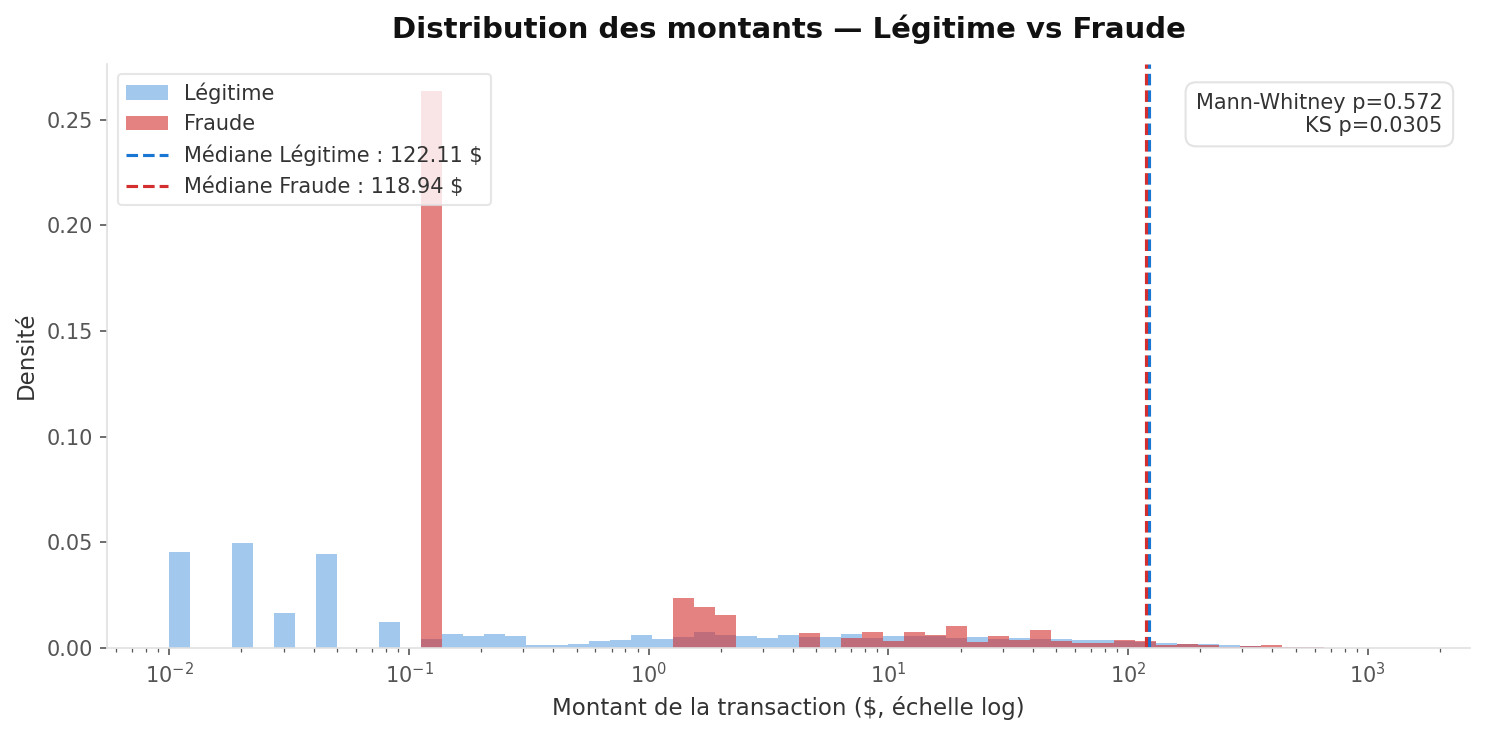

In [7]:
fraud_amt = df[df['is_fraud'] == 1]['amount']
legit_amt = df[df['is_fraud'] == 0]['amount']

# ── Tests Statistiques ──────────────────────────────────────
stat, p_mw  = mannwhitneyu(fraud_amt, legit_amt, alternative='two-sided')
stat, p_ks  = ks_2samp(fraud_amt, legit_amt)

print("── Test U de Mann-Whitney ──────────────────────────")
print(f"   Valeur p : {p_mw:.4f} → {'✗ Pas de différence significative' if p_mw > 0.05 else '✓ Différence significative'}")

print("\n── Test de Kolmogorov-Smirnov ──────────────────────")
print(f"   Valeur p : {p_ks:.4f} → {'✗ Même distribution' if p_ks > 0.05 else '✓ Distributions différentes'}")

# ── Graphique ───────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))

# Création des intervalles (bins) pour l'échelle logarithmique
bins = np.logspace(np.log10(0.01), np.log10(df['amount'].max() + 1), 60)

ax.hist(legit_amt + 0.01, bins=bins, color=LEGIT_COLOR, alpha=0.4, density=True, label='Légitime')
ax.hist(fraud_amt + 0.01, bins=bins, color=FRAUD_COLOR, alpha=0.6, density=True, label='Fraude')

ax.axvline(legit_amt.median(), color=LEGIT_COLOR, linestyle='--', linewidth=1.5, label=f'Médiane Légitime : {legit_amt.median():.2f} $')
ax.axvline(fraud_amt.median(), color=FRAUD_COLOR, linestyle='--', linewidth=1.5, label=f'Médiane Fraude : {fraud_amt.median():.2f} $')

ax.set_xscale('log')
ax.set_xlabel('Montant de la transaction ($, échelle log)')
ax.set_ylabel('Densité')
ax.set_title('Distribution des montants — Légitime vs Fraude', fontweight='bold', pad=12)
ax.legend(loc='upper left')

# Boîte d'annotation des résultats statistiques (adaptée au thème clair)
ax.text(0.98, 0.95, f'Mann-Whitney p={p_mw:.3f}\nKS p={p_ks:.4f}',
        transform=ax.transAxes, ha='right', va='top',
        fontsize=10, color='#333333',
        bbox=dict(facecolor='#FFFFFF', edgecolor='#E0E0E0', boxstyle='round,pad=0.5', alpha=0.9))

plt.tight_layout()

# ── Sauvegarde ──────────────────────────────────────────────
BASE_DIR = Path().resolve().parent
PLOT_DIR = BASE_DIR / 'notebooks' / 'plots'
PLOT_DIR.mkdir(parents=True, exist_ok=True)
save_path = PLOT_DIR / 'amount_distribution.png'

plt.savefig(save_path, bbox_inches='tight', dpi=300)
print(f"\nGraphique sauvegardé avec succès dans : {save_path}")

plt.show()

## Observations du graphique
### Observation 1 — Pic rose massif à 10⁻¹ (= 0.1$)
C'est le signal le plus visible du plot. Une concentration énorme de transactions frauduleuses autour de 0.10$ qui n'existe pas du tout côté légitime. C'est la signature du card probing — micro-transaction de test avant exploitation.
### Observation 2 — Légit étalé sur les petits montants (10⁻² à 10⁰)
Les barres turquoise sont présentes de 0.01$ à 1$ de façon régulière — ce sont des achats normaux variés : café, transport, petits achats quotidiens.
### Observation 3 — Médianes presque identiques (~100$)
Les deux lignes pointillées sont collées l'une à l'autre à 10² (≈ 100$). Visuellement et statistiquement (Mann-Whitney p=0.572), le montant médian ne distingue pas les deux classes.
### Observation 4 — Queues similaires vers 10³ (1000$+)
Les deux classes ont des transactions élevées. Les gros montants ne sont donc pas une signature de fraude dans ce dataset.

## Notes — Rôle des deux tests

### Mann-Whitney U — Rôle
Répondre à la question : "Le montant typique d'une fraude est-il différent de celui d'une transaction légitime ?"
Il compare les positions centrales des deux groupes sans supposer une distribution normale. C'est le test qu'on utilise quand les données sont asymétriques ou avec des outliers — exactement le cas des montants financiers.
Résultat ici : p = 0.572
→ Non, le montant typique d'une fraude ne se distingue pas de celui d'une transaction légitime. amount seule ne peut pas identifier une fraude.

### Kolmogorov-Smirnov — Rôle
Répondre à la question : "Les fraudes et les légitimes ont-elles la même façon de se distribuer sur toute la plage de montants ?"
Il est plus puissant que Mann-Whitney car il analyse toute la courbe et non juste le centre. Il détecte les différences aux extrêmes — comme un pic inhabituel à 0.1$ — que Mann-Whitney ignore complètement.
Résultat ici : p = 0.0305
→ Oui, les deux distributions ont des formes différentes. Le pic de micro-transactions à 0.1$ côté fraude suffit à rendre les deux courbes statistiquement distinctes même si leurs médianes sont identiques.

ANALYSE DES CARACTÉRISTIQUES (Moyennes)

Graphique sauvegardé avec succès dans : C:\Users\Lenovo T470\OneDrive\Documents\GitHub\fraud-detection-realtime\notebooks\plots\feature_analysis_pie.png


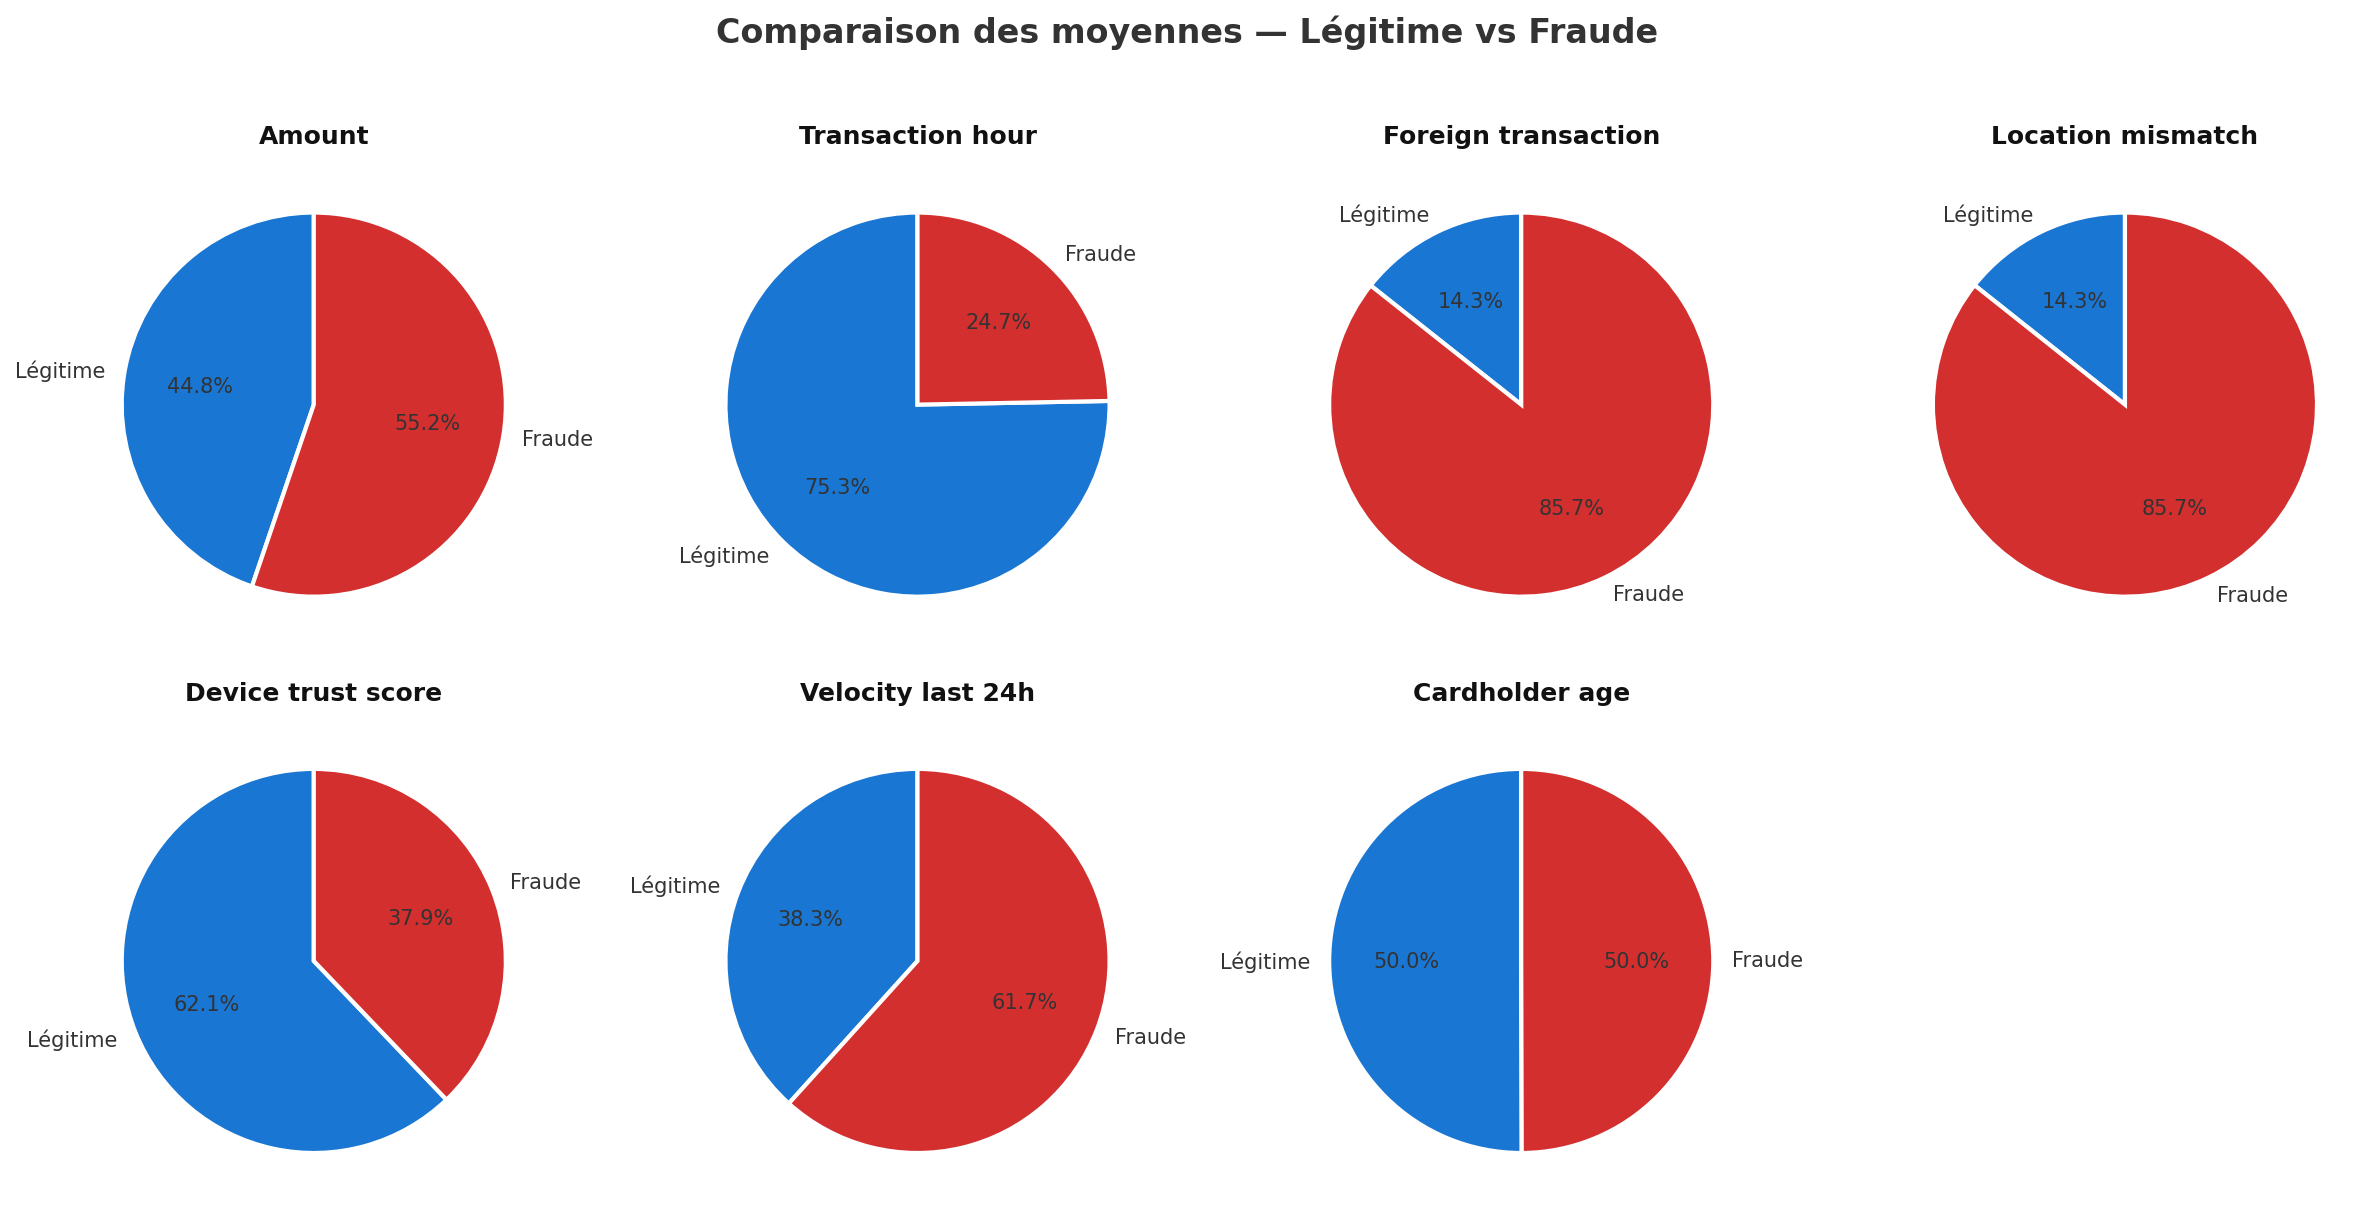

In [8]:
num_features = ['amount', 'transaction_hour', 'foreign_transaction',
                'location_mismatch', 'device_trust_score',
                'velocity_last_24h', 'cardholder_age']

fraud = df[df['is_fraud'] == 1]
legit = df[df['is_fraud'] == 0]

# Création de la figure (le fond blanc est géré automatiquement par ta première cellule)
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, feat in enumerate(num_features):
    ax = axes[i]

    mean_legit = legit[feat].mean()
    mean_fraud = fraud[feat].mean()
    
    # Rend le nom de la variable plus joli pour le titre (ex: 'Cardholder age')
    display_name = feat.replace('_', ' ').capitalize()

    ax.pie(
        [mean_legit, mean_fraud],
        labels=['Légitime', 'Fraude'],
        colors=PALETTE,
        autopct='%1.1f%%',
        startangle=90,
        wedgeprops=dict(edgecolor='white', linewidth=2),
        textprops=dict(fontsize=10, color='#333333') # Texte gris foncé, lisible sur fond blanc
    )
    ax.set_title(display_name, fontsize=12, fontweight='bold', pad=10)

# Cacher le dernier subplot vide (puisqu'il y a 7 features pour 8 cases)
axes[-1].set_visible(False)

plt.suptitle('Comparaison des moyennes — Légitime vs Fraude',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()

# ── Sauvegarde ──────────────────────────────────────────────
BASE_DIR = Path().resolve().parent
PLOT_DIR = BASE_DIR / 'notebooks' / 'plots'
PLOT_DIR.mkdir(parents=True, exist_ok=True)
save_path = PLOT_DIR / 'feature_analysis_pie.png'

plt.savefig(save_path, bbox_inches='tight', dpi=300)
print(f"Graphique sauvegardé avec succès dans : {save_path}")

plt.show()

Exemple concret avec foreign_transaction:
mean_legit = 0.091   (9.1% des légitimes sont étrangères)
mean_fraud  = 0.543  (54.3% des fraudes sont étrangères)

total = 0.091 + 0.543 = 0.634

% Legit = 0.091 / 0.634 = 14.3%  ✓ ce qu'on voit dans le cercle
% Fraud = 0.543 / 0.634 = 85.7%  ✓ ce qu'on voit dans le cercle

Le cercle ne montre pas une distribution — il montre qui a la valeur moyenne la plus haute. Plus la part d'une classe est grande, plus sa moyenne domine l'autre.
Cercle équilibré  (50/50)  →  feature inutile  — même moyenne
Cercle déséquilibré (85/15) →  feature utile   — moyennes très différentes

TENDANCES TEMPORELLES DES TRANSACTIONS

Graphique sauvegardé avec succès dans : C:\Users\Lenovo T470\OneDrive\Documents\GitHub\fraud-detection-realtime\notebooks\plots\temporal_patterns.png



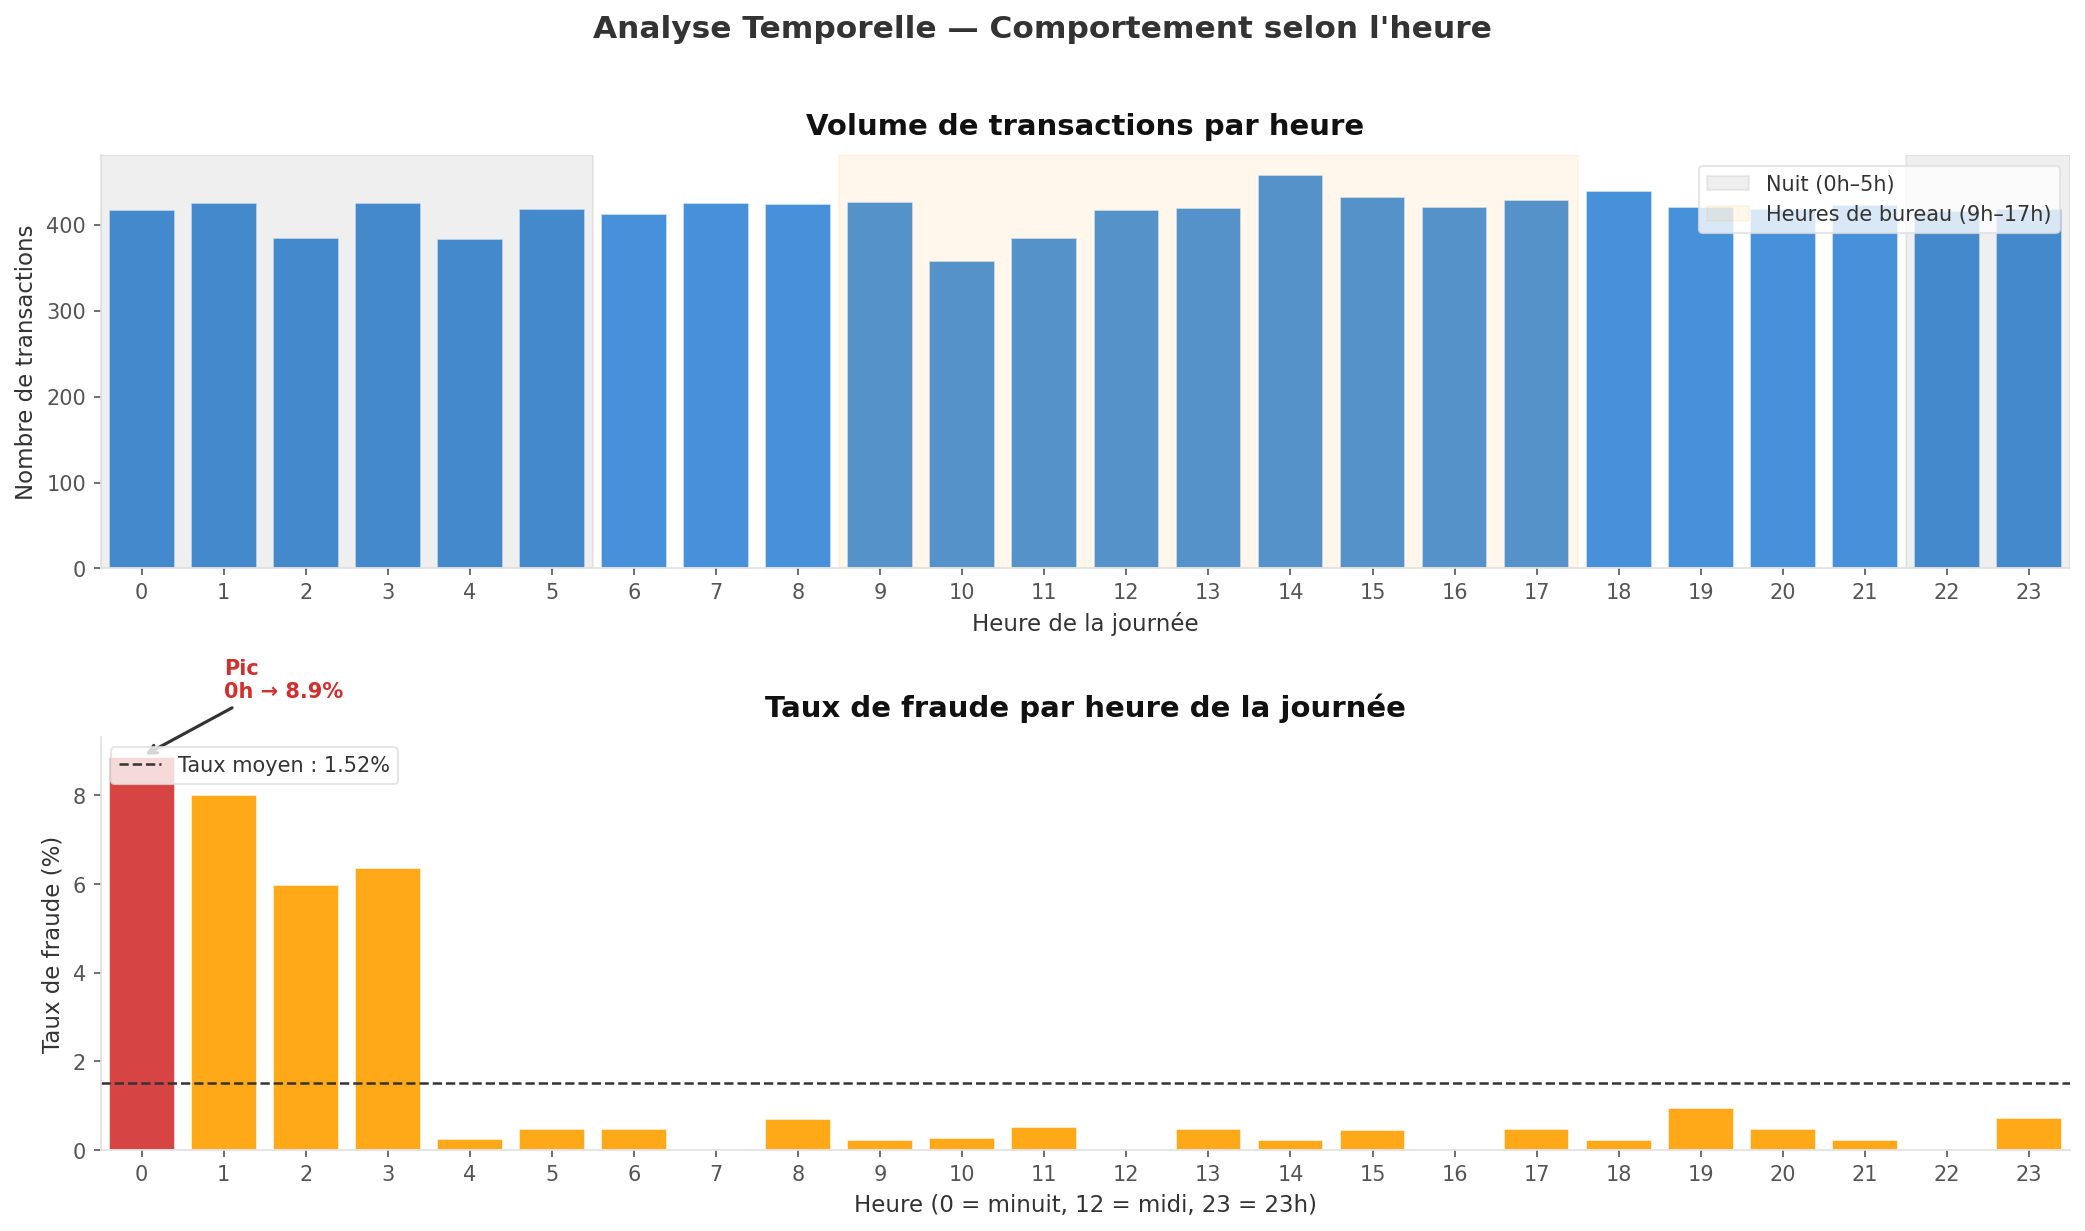

── RÉSUMÉ STATISTIQUE ──────────────────────
 Taux de fraude moyen        : 1.52%
 Heure avec le plus de fraude: 0h (8.9%)
 Heure la plus sûre          : 7h


In [9]:
# Préparation des données
hourly        = df.groupby('transaction_hour').size().reset_index(name='total')
hourly_fraud  = df[df['is_fraud'] == 1].groupby('transaction_hour').size().reset_index(name='fraud')
hourly        = hourly.merge(hourly_fraud, on='transaction_hour', how='left').fillna(0)
hourly['fraud_rate'] = (hourly['fraud'] / hourly['total']) * 100

fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# ── Panel 1 : Volume par heure ───────────────────────────────
ax1 = axes[0]
ax1.bar(hourly['transaction_hour'], hourly['total'],
        color=LEGIT_COLOR, alpha=0.8, edgecolor='white', linewidth=0.8)

ax1.set_xlim(-0.5, 23.5)
ax1.set_xticks(range(24))
ax1.set_xlabel('Heure de la journée')
ax1.set_ylabel('Nombre de transactions')
ax1.set_title('Volume de transactions par heure', fontweight='bold', pad=10)

# Zones Nuit / Jour (Couleurs très subtiles pour fond blanc)
ax1.axvspan(-0.5,  5.5, color='#333333', alpha=0.08, label='Nuit (0h–5h)')
ax1.axvspan( 8.5, 17.5, color='#FFA000', alpha=0.08, label='Heures de bureau (9h–17h)')
ax1.axvspan(21.5, 23.5, color='#333333', alpha=0.08)
ax1.legend(loc='upper right')

# ── Panel 2 : Taux de fraude par heure ──────────────────────
ax2 = axes[1]

# Barres de base en couleur d'accent (orange/rose clair), pic en rouge (FRAUD_COLOR)
bar_colors = [FRAUD_COLOR if r == hourly['fraud_rate'].max() else ACCENT_COLOR
              for r in hourly['fraud_rate']]

ax2.bar(hourly['transaction_hour'], hourly['fraud_rate'],
        color=bar_colors, alpha=0.9, edgecolor='white', linewidth=0.8)

ax2.set_xlim(-0.5, 23.5)
ax2.set_xticks(range(24))
ax2.set_xlabel('Heure (0 = minuit, 12 = midi, 23 = 23h)')
ax2.set_ylabel('Taux de fraude (%)')
ax2.set_title('Taux de fraude par heure de la journée', fontweight='bold', pad=10)

# Ligne de moyenne
avg_rate = hourly['fraud_rate'].mean()
ax2.axhline(avg_rate, color='#333333', linestyle='--',
            linewidth=1.2, label=f'Taux moyen : {avg_rate:.2f}%')
ax2.legend(loc='upper left')

# Annotation de l'heure de pic
peak_hour = hourly.loc[hourly['fraud_rate'].idxmax(), 'transaction_hour']
peak_rate = hourly['fraud_rate'].max()

ax2.annotate(f'Pic\n{int(peak_hour)}h → {peak_rate:.1f}%',
             xy=(peak_hour, peak_rate),
             xytext=(peak_hour + 1, peak_rate + (peak_rate * 0.15)), # Décalage dynamique
             arrowprops=dict(arrowstyle='->', color='#333333', lw=1.5),
             color=FRAUD_COLOR, fontweight='bold', fontsize=10)

plt.suptitle('Analyse Temporelle — Comportement selon l\'heure',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()

# ── Sauvegarde ──────────────────────────────────────────────
BASE_DIR = Path().resolve().parent
PLOT_DIR = BASE_DIR / 'notebooks' / 'plots'
PLOT_DIR.mkdir(parents=True, exist_ok=True)
save_path = PLOT_DIR / 'temporal_patterns.png'

plt.savefig(save_path, bbox_inches='tight', dpi=300)
print(f"Graphique sauvegardé avec succès dans : {save_path}\n")

plt.show()

# ── Print résumé ─────────────────────────────────────────────
print("── RÉSUMÉ STATISTIQUE ──────────────────────")
print(f" Taux de fraude moyen        : {avg_rate:.2f}%")
print(f" Heure avec le plus de fraude: {int(peak_hour)}h ({peak_rate:.1f}%)")
print(f" Heure la plus sûre          : {int(hourly.loc[hourly['fraud_rate'].idxmin(), 'transaction_hour'])}h")

Analyse Temporelle
- Volume par heure : Le volume de transactions est remarquablement uniforme sur les 24 heures (entre 350 et 450 transactions par heure). L'absence de creux nocturne et de pic diurne confirme la nature synthétique de ce dataset.
- Taux de fraude par heure : C'est l'indicateur le plus fort. On observe un pic massif entre 0h et 3h du matin. Ces 4 premières heures de la nuit concentrent les taux de fraude les plus élevés.

Synthèse de l'Exploration des Données (EDA)
1. Classe cible — Déséquilibre extrême
Le dataset contient 98.49% de transactions légitimes contre seulement 1.51% de fraudes (151 cas sur 10 000). Ce déséquilibre est le défi central du projet. L'accuracy (précision globale) sera une métrique trompeuse ; les métriques à privilégier pour évaluer notre modèle seront le F1-score, le Recall et la courbe ROC-AUC.

2. Features les plus discriminantes (Signaux Forts)

- foreign_transaction et location_mismatch sont les signaux les plus forts. 54% des fraudes sont des transactions étrangères (contre 9% des légitimes) et 48% présentent une incohérence géographique (contre 8%).

- device_trust_score est le troisième signal majeur : les appareils utilisés pour les fraudes ont un score moyen très bas de 38, contre 62 pour les légitimes.

- velocity_last_24h révèle le comportement d'urgence des fraudeurs : 3.2 transactions en moyenne contre 2.0. Multiplier rapidement les achats avant le blocage de la carte est une signature typique.

3. Features à signal faible ou contextuel

- amount ne discrimine pas les deux classes sur la médiane (122$ vs 118$, test de Mann-Whitney p=0.572). Son seul signal utile est le pic de micro-transactions à 0.1$ côté fraude — signature typique du card probing (test de validité de la carte) — confirmé par le test KS (p=0.030).

- cardholder_age ne montre aucune différence significative entre les deux classes. À utiliser avec précaution ou à exclure.

- transaction_hour est un signal faible pris isolément, mais très puissant contextuellement (la concentration nocturne).

4. Pattern comportemental du fraudeur
En combinant toutes ces observations, le profil type d'une transaction frauduleuse dans notre système se définit par :

Heure : Entre 0h et 3h (Nuit)
Localisation : Transaction internationale (1) avec adresse incohérente (1)
Confiance : Score de l'appareil très bas (< 40)
Vélocité : Fréquence élevée (> 3 transactions en 24h)
Montant : Soit très faible (test de carte à ~0.1$), soit très élevé.